<a href="https://colab.research.google.com/github/susanajara/Analitica/blob/main/taller2_caso_coordinadora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EJERCICIO PRÁCTICO (ENTREGABLE)

## CASO DE ESTUDIO
CASO DE ESTUDIO

COORDINADORA MERCANTIL S.A. es una empresa colombiana líder en logística y distribución, con más de 40 años de operación en el país. Su unidad de e-commerce, Coordinadora Fulfillment, gestiona actualmente más de 120 centros de distribución a lo largo del territorio nacional, procesando en promedio 2.8 millones de pedidos mensuales para más de 15.000 comercios digitales activos.

La empresa está interesada en desarrollar un sistema por adaptación y aprendizaje que le permita proyectar, desde la gestión de sus riesgos operacionales, el valor potencial de pérdidas asociadas a fallas en la cadena de entrega de última milla en el área metropolitana del Valle de Aburrá.

Las barreras que serán utilizadas para este proceso son las siguientes:

- Frecuencia: indica el número de pedidos no entregados a tiempo por mes en los centros de distribución monitoreados (número de eventos/mes).

- Severidad: es el costo promedio de gestión por cada incidente operacional, incluyendo reenvíos, penalizaciones contractuales y pérdida de mercancía (COP Miles/evento).

- Distribución de Pérdidas: es el producto entre la frecuencia y la severidad. Esta distribución agrega los parámetros de riesgo y permite estimar el capital en riesgo operacional (OpVaR) bajo el enfoque de Distribución Agregada de Pérdidas (LDA).

###0. las librerias ya fueron importadas


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

###1.creamos el data frame

A continuación, se describen los títulos de las columnas en el DataFrame:

*   **Pedidos_Procesados_Mes**: Representa la cantidad total de pedidos que fueron procesados en un mes específico, simulando la carga de trabajo o volumen de operaciones.
*   **Valor_Operado_COP_Miles**: Indica el valor monetario total, en miles de COP (pesos colombianos), de las operaciones o mercancías gestionadas durante un mes.
*   **Frecuencia**: Es el número de eventos o incidentes (pedidos no entregados a tiempo) ocurridos en un mes.
*   **Severidad_COP_Miles**: Mide el costo promedio, en miles de COP, asociado a cada incidente operacional, como reenvíos o penalizaciones.
*   **Distribucion_Perdidas_COP_Miles**: Es el resultado de multiplicar la Frecuencia por la Severidad, representando la pérdida total estimada en miles de COP debido a incidentes operacionales.
*   **Tipo_Evento**: Categoriza la naturaleza del incidente ocurrido, como 'Entrega Fallida', 'Daño en Mercancía', etc.
*   **Nivel_Impacto**: Un valor numérico (1 a 5) que clasifica la magnitud del impacto de un incidente, correlacionado positivamente con la Severidad.
*   **Nivel_Gestion**: Describe el tipo de estrategia o acción de gestión requerida para el incidente, en función de su Nivel de Impacto.
*   **Costo_Por_Pedido_USD**: El costo promedio, en USD, asociado a cada pedido, el cual aumenta progresivamente según el Nivel de Impacto del incidente.

In [ ]:
import numpy as np
import pandas as pd

# Establecer una semilla para reproducibilidad
np.random.seed(42)

N = 1000 # Número de registros

# 2. Pedidos_Procesados_Mes (500 a 5,000)
CDB = pd.DataFrame({'Pedidos_Procesados_Mes': np.random.randint(500, 5001, N)})

# 3. Valor_Operado_USD (12,500 a 200,000 USD)
# Los rangos originales de 50,000 a 800,000 COP_Miles se convierten a USD.
CDB['Valor_Operado_USD'] = np.random.uniform(12500, 200000, N)

# 4. Frecuencia (2 a 80, asimetría positiva > 1.0 con Poisson)
# Usar un lambda bajo para asegurar asimetría positiva en la distribución de Poisson
# Los valores generados se recortarán para ajustarse al rango [2, 80]
lambda_freq_param = 8 # Un valor lambda entre 5 y 15 suele dar buena asimetría para este rango
frecuencia_raw = np.random.poisson(lambda_freq_param, N)
CDB['Frecuencia'] = np.clip(frecuencia_raw, 2, 80)

# 5. Severidad_USD (12.5 a 500 USD)
# Ajustar mean_log y sigma_log para obtener asimetría positiva y valores en el rango deseado en USD
# Un valor mediano de ~80 USD y una dispersión adecuada.
mean_log_usd = 4.38 # log(80) ~ 4.38, donde 80 es la mediana esperada en USD
sigma_log_usd = 0.9  # Ajustar para la dispersión y asimetría deseada

severidad_raw_usd = np.random.lognormal(mean_log_usd, sigma_log_usd, N)
CDB['Severidad_USD'] = np.clip(severidad_raw_usd, 12.5, 500)

# 6. Distribucion_Perdidas_USD (Frecuencia * Severidad_USD)
CDB['Distribucion_Perdidas_USD'] = CDB['Frecuencia'] * CDB['Severidad_USD']

# 7. Tipo_Evento
tipo_eventos = ['Entrega Fallida', 'Daño en Mercancía', 'Error de Inventario', 'Falla de Sistema', 'Incidente Laboral']
CDB['Tipo_Evento'] = np.random.choice(tipo_eventos, N, p=[0.3, 0.25, 0.2, 0.15, 0.1]) # Distribución de probabilidad ajustada

# 8. Nivel_Impacto (1 a 5, correlacionado positivamente con Severidad_USD)
# Primero, ordenamos el DataFrame por severidad para asignar el impacto de forma correlacionada
CDB_sorted = CDB.sort_values(by='Severidad_USD').reset_index(drop=True)

# Asignamos Nivel_Impacto en función de los quintiles de Severidad para lograr la correlación
def assign_impact_level(severity_series):
    impact_levels = np.zeros(len(severity_series), dtype=int)
    p20 = severity_series.quantile(0.2)
    p40 = severity_series.quantile(0.4)
    p60 = severity_series.quantile(0.6)
    p80 = severity_series.quantile(0.8)

    impact_levels[severity_series <= p20] = 1
    impact_levels[(severity_series > p20) & (severity_series <= p40)] = 2
    impact_levels[(severity_series > p40) & (severity_series <= p60)] = 3
    impact_levels[(severity_series > p60) & (severity_series <= p80)] = 4
    impact_levels[severity_series > p80] = 5
    return impact_levels

CDB_sorted['Nivel_Impacto'] = assign_impact_level(CDB_sorted['Severidad_USD'])

# Mezclar el DataFrame para que el orden no esté ligado a la severidad
CDB = CDB_sorted.sample(frac=1, random_state=42).reset_index(drop=True)

# 9. Nivel_Gestion (derivado de Nivel_Impacto)
nivel_gestion_map = {
    1: 'Control Básico de Rutina',
    2: 'Control Periódico Preventivo',
    3: 'Monitoreo Regular y Correctivos',
    4: 'Control Rigurosamente Planificado',
    5: 'Intervención Crítica Inmediata'
}
CDB['Nivel_Gestion'] = CDB['Nivel_Impacto'].map(nivel_gestion_map)

# 10. Costo_Por_Pedido_USD (aumenta progresivamente con Nivel_Impacto)
# Definir los rangos de costo para cada Nivel_Impacto en USD
costo_por_impacto = {
    1: lambda: np.random.uniform(0.05, 0.20),
    2: lambda: np.random.uniform(0.20, 0.50),
    3: lambda: np.random.uniform(0.50, 0.90),
    4: lambda: np.random.uniform(0.90, 1.20),
    5: lambda: np.random.uniform(1.20, 1.50)
}

# Aplicar la función lambda para generar un costo por pedido en USD
CDB['Costo_Por_Pedido_USD'] = CDB['Nivel_Impacto'].apply(lambda x: costo_por_impacto[x]())

print("DataFrame generado:")
display(CDB.head())
print("\nEstadísticas descriptivas del DataFrame:")
display(CDB.describe())

print("\nSkewness de Frecuencia:", CDB['Frecuencia'].skew())
print("Skewness de Severidad_USD:", CDB['Severidad_USD'].skew())
print("Skewness de Distribucion_Perdidas_USD:", CDB['Distribucion_Perdidas_USD'].skew())

DataFrame generado:


,Pedidos_Procesados_Mes,Valor_Operado_USD,Frecuencia,Severidad_USD,Distribucion_Perdidas_USD,Tipo_Evento,Nivel_Impacto,Nivel_Gestion,Costo_Por_Pedido_USD
0,1173,110231.399841,8,85.730651,685.845207,Daño en Mercancía,3,Monitoreo Regular y Correctivos,0.839103
1,1752,138143.006490,9,140.658885,1265.929966,Error de Inventario,4,Control Rigurosamente Planificado,1.012992
2,4952,167096.383793,7,141.144682,988.012776,Error de Inventario,4,Control Rigurosamente Planificado,1.072174
3,4929,56103.379694,6,117.157168,702.943008,Entrega Fallida,4,Control Rigurosamente Planificado,0.908152
4,2145,159470.501894,4,64.458560,257.834240,Falla de Sistema,3,Monitoreo Regular y Correctivos,0.605289



Estadísticas descriptivas del DataFrame:


,Pedidos_Procesados_Mes,Valor_Operado_USD,Frecuencia,Severidad_USD,Distribucion_Perdidas_USD,Nivel_Impacto,Costo_Por_Pedido_USD
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2815.422000,105887.375298,7.925000,111.853189,888.358536,3.000000,0.712948
std,1255.514921,53634.698783,2.893397,99.719508,863.204185,1.414921,0.453820
min,503.000000,12544.535670,2.000000,12.500000,25.000000,1.000000,0.050169
25%,1749.500000,58844.821513,6.000000,42.911493,287.025592,2.000000,0.274709
50%,2862.500000,108329.553372,8.000000,80.341347,588.473000,3.000000,0.681755
75%,3849.500000,151932.051117,10.000000,146.945217,1198.815313,4.000000,1.109592
max,4999.000000,199878.781169,18.000000,500.000000,6000.000000,5.000000,1.495946



Skewness de Frecuencia: 0.2502335098084531
Skewness de Severidad_USD: 1.799325335627482
Skewness de Distribucion_Perdidas_USD: 2.040766065283536


###2. realizamos el histograma

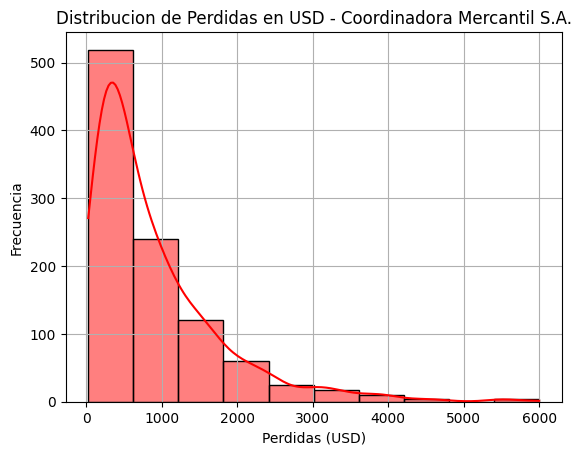

In [ ]:
Freq = CDB.iloc[:,2] # Extrae la columna 'Frecuencia' del DataFrame 'CDB'
Sev = CDB.iloc[:,3] # Extrae la columna 'Severidad_USD' del DataFrame 'CDB'
LDA_Coordinadora = Freq * Sev # Calcula la 'Distribución de Pérdidas' multiplicando Frecuencia por Severidad

plt.figure() # Crea una nueva figura para el gráfico
sns.histplot(LDA_Coordinadora, color='red', bins=10, kde=True) # Genera un histograma de la 'Distribución de Pérdidas' (LDA)
plt.title('Distribucion de Perdidas en USD - Coordinadora Mercantil S.A.') # Establece el título del gráfico
plt.xlabel('Perdidas (USD)') # Etiqueta el eje X como 'Pérdidas (USD)'
plt.ylabel('Frecuencia') # Etiqueta el eje Y como 'Frecuencia'
plt.grid() # Agrega una cuadrícula al gráfico
plt.show() # Muestra el gráfico generado

###interpretación histograma

Incidentes de baja magnitud (25 USD - 622.5 USD): Un total de 519 incidentes, lo que representa la mayoría (51.9%) de las pérdidas. Estos son los eventos más frecuentes.

Incidentes de magnitud media (622.5 USD - 1220 USD): Se registraron 240 incidentes, el 24% del total.

Incidentes de magnitud media-alta (1220 USD - 1817.5 USD): Hubo 121 incidentes, el 12.1%.

Incidentes de magnitud alta (1817.5 USD - 2415 USD): Se observaron 60 incidentes, el 6%.

Incidentes de muy alta magnitud (2415 USD - 6000 USD): A medida que la magnitud de la pérdida aumenta, el número de incidentes disminuye significativamente. Por ejemplo:
De 2415 USD a 3012.5 USD: 24 incidentes.
De 3012.5 USD a 3610 USD: 18 incidentes.
De 3610 USD a 4207.5 USD: 10 incidentes.
De 4207.5 USD a 4805 USD: 4 incidentes.
De 4805 USD a 5402.5 USD: 0 incidentes.
De 5402.5 USD a 6000 USD: 4 incidentes. (Estos son los eventos menos frecuentes pero de mayor costo individual).

In [ ]:
NI = 10
counts, limits = np.histogram(LDA_Coordinadora, bins=NI) # Agrupa los datos en 10 intervalos
LI = limits[:-1] # Límites inferiores del histograma
LS = limits[1:] # Límites superiores del histograma
fi = counts / sum(counts) # Frecuencia relativa (porcentaje de datos por intervalos)
MC = (LI + LS) / 2 # Punto medio de cada intervalo

df = pd.DataFrame(np.column_stack((LI, LS, counts, fi, MC)))
df.columns = ["LI", "LS", "ND", "fi", "MC"]
display(df)

,LI,LS,ND,fi,MC
0,25.0,622.5,519.0,0.519,323.75
1,622.5,1220.0,240.0,0.240,921.25
2,1220.0,1817.5,121.0,0.121,1518.75
3,1817.5,2415.0,60.0,0.060,2116.25
4,2415.0,3012.5,24.0,0.024,2713.75
5,3012.5,3610.0,18.0,0.018,3311.25
6,3610.0,4207.5,10.0,0.010,3908.75
7,4207.5,4805.0,4.0,0.004,4506.25
8,4805.0,5402.5,0.0,0.000,5103.75
9,5402.5,6000.0,4.0,0.004,5701.25


###3. Medidas de tendencia central


In [ ]:


#1 Media - valor esperado de una perdida ( que es lo mas común que pase?)
u=np.sum(MC*fi)
print("Media = ",u)

#2 varianza: indica que tan dispersos estan los datos con respecto a la media
varc=np.sum((MC-u)**2*fi)
print("Varianza = ",varc)

#3 desviación standar
sigma=np.sqrt(varc)
print("Desviación estandar = ",sigma)

#4 intervalo de variación de la perdidas
# en este intervalo se encuentra el 95% de los datos (2*sigma)
# en este intervalo se encuentran el 68% de los datos (1*sigma)
print(" el limite inferior es =",u-2*sigma)
print(" el limite superior es =",u+2*sigma)

#5 coeficiente de asimetria
cas=np.sum((MC-u)**3*fi)/((sigma**3))
print("Coeficiente de asimetria = ",cas)


#6. coeficiente de curtosis (tarea)
curt=np.sum((MC-u)**4*fi)/((sigma**4))
print("Coeficiente de curtosis = ",curt)

Media =  904.5199999999999
Varianza =  725870.8196
Desviación estandar =  851.9805277117547
 el limite inferior es = -799.4410554235095
 el limite superior es = 2608.481055423509
Coeficiente de asimetria =  2.143644304435685
Coeficiente de curtosis =  8.867146595107528


# Análisis

Media (Promedio de Pérdidas): 904.52 USD

Explicación Sencilla: Este es el valor de pérdida más común o el "promedio" que Coordinadora puede esperar en cada incidente en su cadena de entrega. Si sumamos todas las pérdidas y dividimos por el número de incidentes, obtendríamos algo cercano a este valor.
Interpretación para Coordinadora: En promedio, cada vez que hay un fallo en la entrega, le cuesta a la empresa unos 904.52 USD. Es un punto de referencia para entender el costo habitual de un incidente.
Varianza y Desviación Estándar (Qué tan dispersas están las pérdidas): Varianza = 725870.82, Desviación Estándar = 851.98 USD

Explicación Sencilla: La desviación estándar nos dice qué tan "diferentes" suelen ser las pérdidas entre sí. Si la desviación es pequeña, todas las pérdidas son muy parecidas al promedio. Si es grande, las pérdidas varían mucho: algunas son mucho más pequeñas que el promedio y otras mucho más grandes.


Interpretación para Coordinadora: Una desviación estándar de 851.98 USD es casi tan grande como la media (904.52 USD). Esto es muy importante: indica que las pérdidas no son uniformes. Coordinadora no solo tiene pérdidas cercanas a los 900 USD; hay una gran variedad, incluyendo muchas pérdidas pequeñas, pero también algunas pérdidas individuales que son significativamente más grandes que el promedio. Esto sugiere una gran incertidumbre en el monto de cada pérdida.
Intervalo de Variación de las Pérdidas (Rango esperable del 95% de las pérdidas): De -799.44 USD a 2608.48 USD

Explicación Sencilla: Este rango nos daría dónde se encuentra la mayoría de las pérdidas. Sin embargo, no podemos tener pérdidas negativas.


Interpretación para Coordinadora: Dado que una pérdida no puede ser negativa, este intervalo, combinado con las otras medidas, nos dice que la mayoría de las pérdidas reales estarán entre 0 USD y aproximadamente 2608.48 USD. El hecho de que el límite inferior calculado sea negativo ya nos indica que la distribución no es simétrica y que hay más espacio hacia los valores altos de pérdida.
Coeficiente de Asimetría (Asimetría de la distribución): 2.14

Explicación Sencilla: Imagina un gráfico de las pérdidas (como el histograma). Si es simétrico, los lados son iguales. Si la asimetría es positiva (como aquí), el gráfico tiene una "cola" larga hacia la derecha. Esto significa que hay pocos eventos que causan pérdidas muy grandes.

Interpretación para Coordinadora: Un valor de 2.14 es un indicador fuerte de riesgo de eventos de alto impacto. Significa que, aunque la mayoría de los incidentes pueden generar pérdidas moderadas (o incluso pequeñas), hay una minoría de incidentes que pueden causar pérdidas significativamente mayores. Coordinadora debe estar preparada para estos eventos "raros pero costosos".
Coeficiente de Curtosis (Probabilidad de eventos extremos): 8.87

Explicación Sencilla: La curtosis nos dice si la distribución tiene un "pico" muy alto en el medio y "colas" muy gordas (muchos valores extremos) o si es más plana con menos valores extremos. Un valor alto (como 8.87) indica un pico alto y colas gordas.


Interpretación para Coordinadora: Este valor alto (8.87 es mucho mayor que el 3 de una distribución "normal") complementa la asimetría. Significa que, no solo hay una cola de pérdidas grandes (asimetría), sino que la probabilidad de que ocurran esas pérdidas muy grandes (o muy pequeñas) es mayor de lo que se esperaría en una situación "normal". En términos prácticos, Coordinadora enfrenta una situación donde los eventos de pérdidas extremas (tanto muy bajas como muy altas) son más probables de lo que una simple media y desviación estándar podrían sugerir. Hay un riesgo real de "sorpresas" con pérdidas inusualmente altas.